## FINE TUNNING CON PSEUDOMÁSCARAS rCMBs
Usamos el modelo con mayor sensibilidad (recall) hasta ahora, que es el 3d fullres smallpatch 50 epochs D112, que detectó 103 TP de los 146 P, para hacer fine tunning con algunas rCMBs. Como pseudomáscaras reales, usaremos un subgrupo de los TP que detectó este propio modelo tras comprobación visual de que son adecuadas, así como un subgrupo de los FN empleando como máscara una segmentación con forma de esfera guiada por intensidad.

Para entrenarlo con rCMB, es necesario tener máscaras de estas lesiones. Se valora usar las predicciones del propio modelo D112 sobre las rCMB, pero dado que infrasegmentan, usamos un algoritmo guiado por intensidad.

Estas imagenes con rCMB reales y sus pseudomascaras se guardan en:
"/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/nnUNet_raw/Dataset115_RealFineTuning"

### Refinamiento de Pseudo-etiquetas (Pseudo-label Refinement)

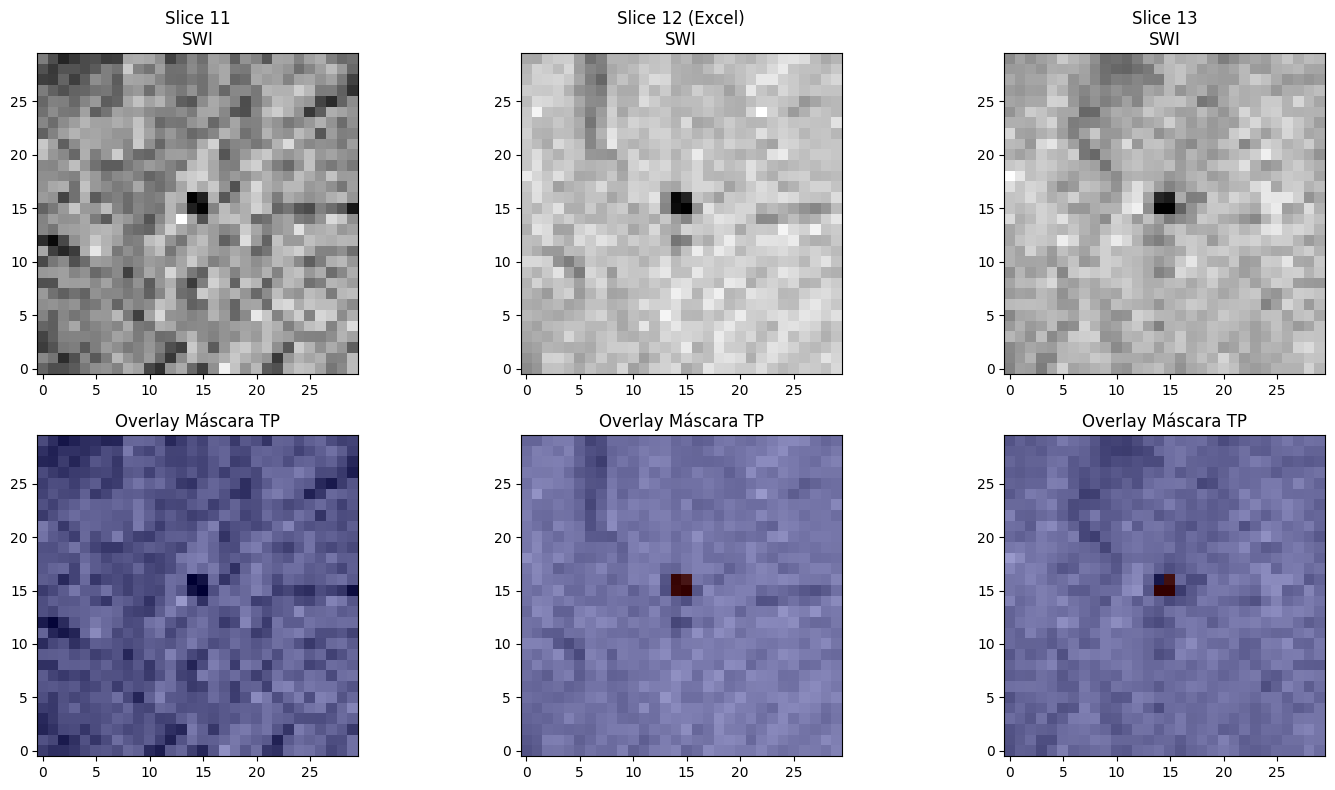

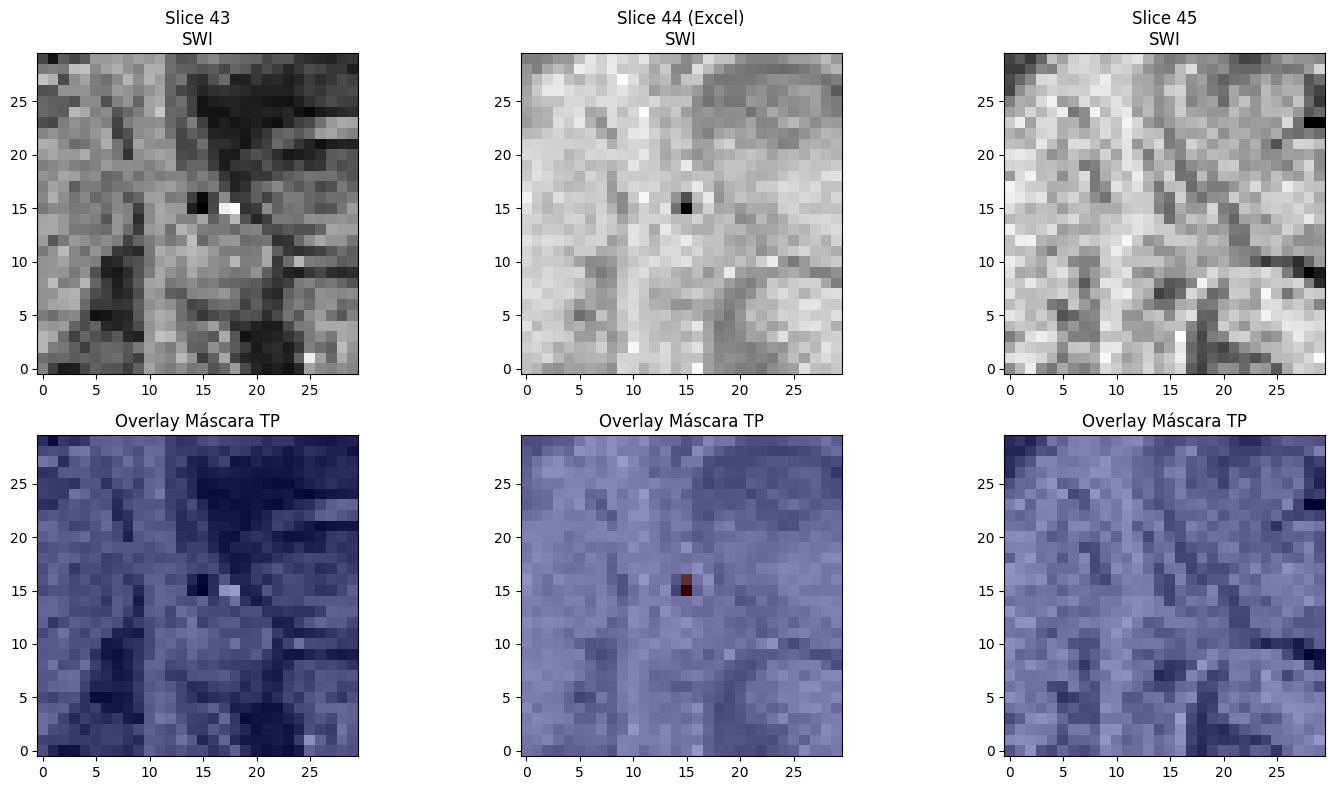

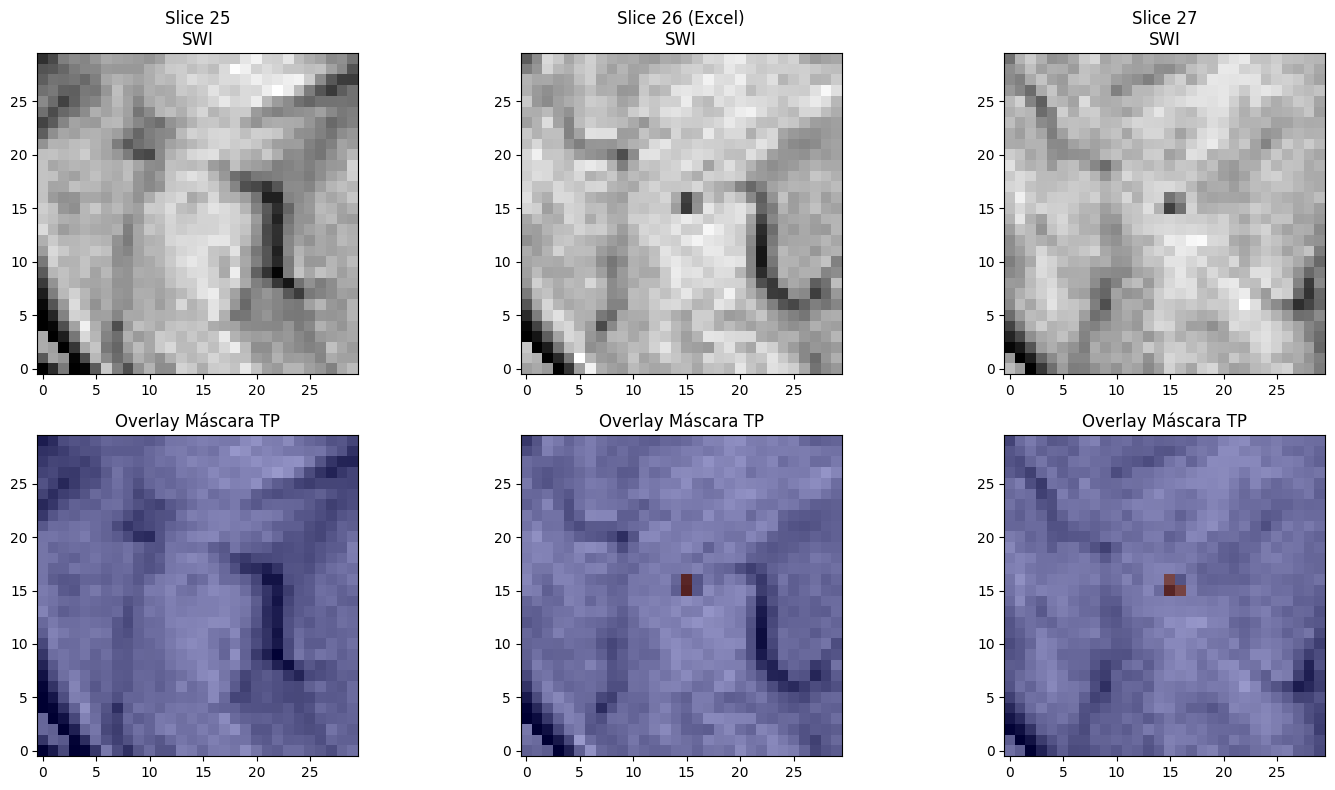

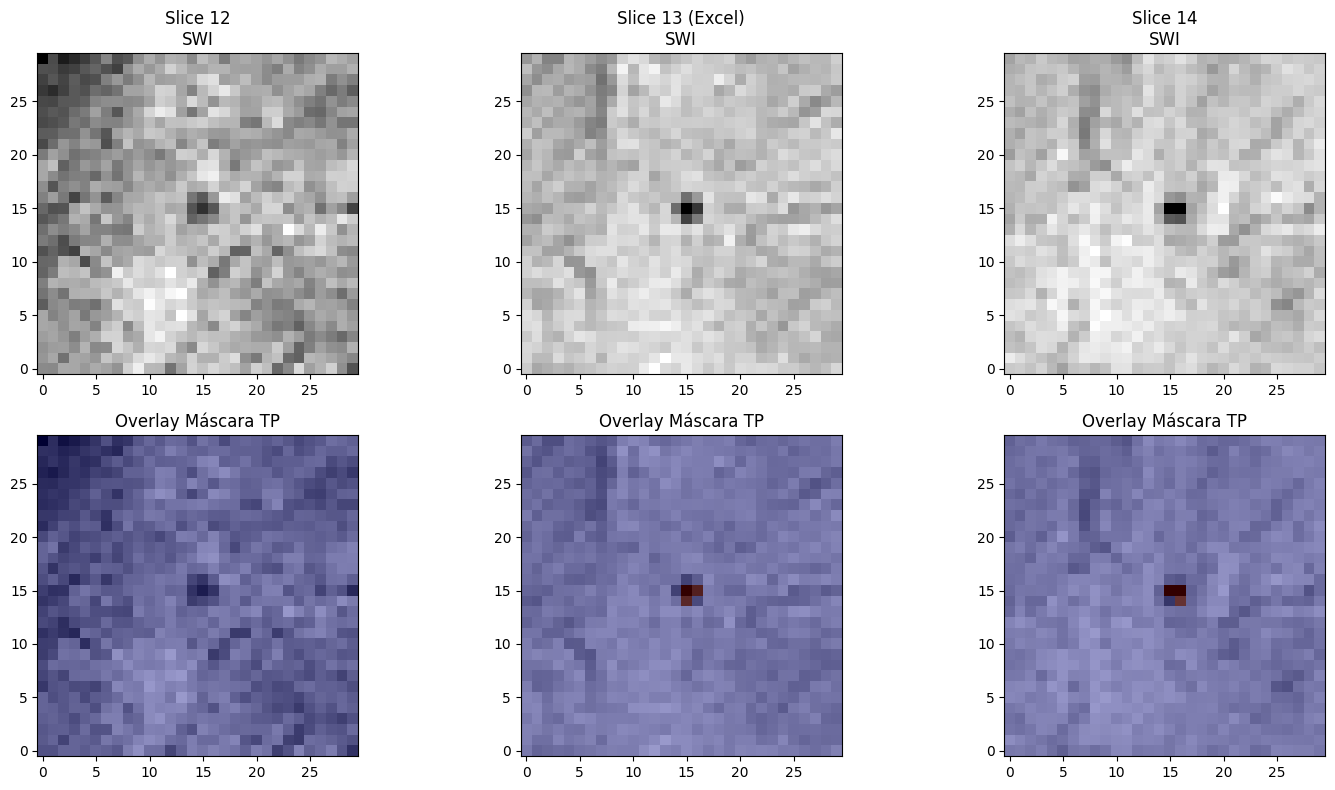

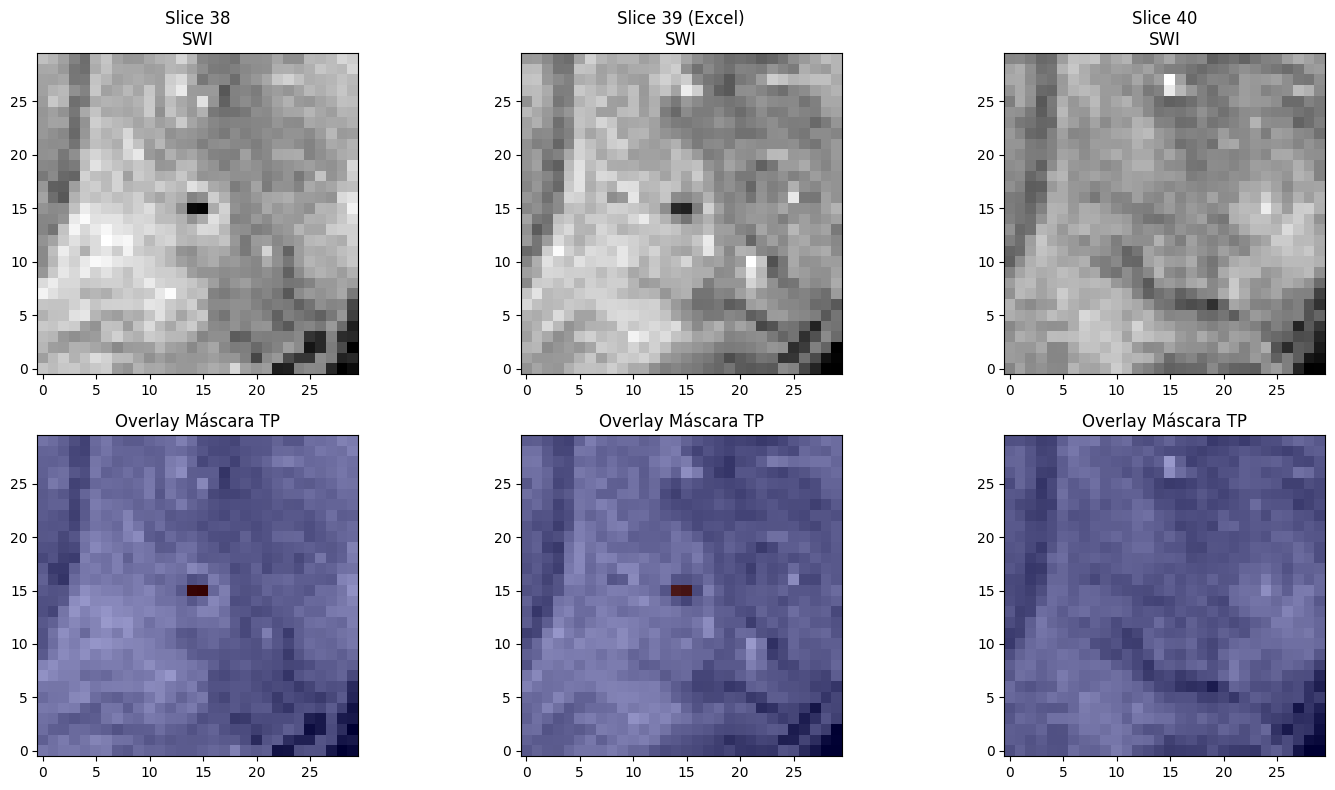

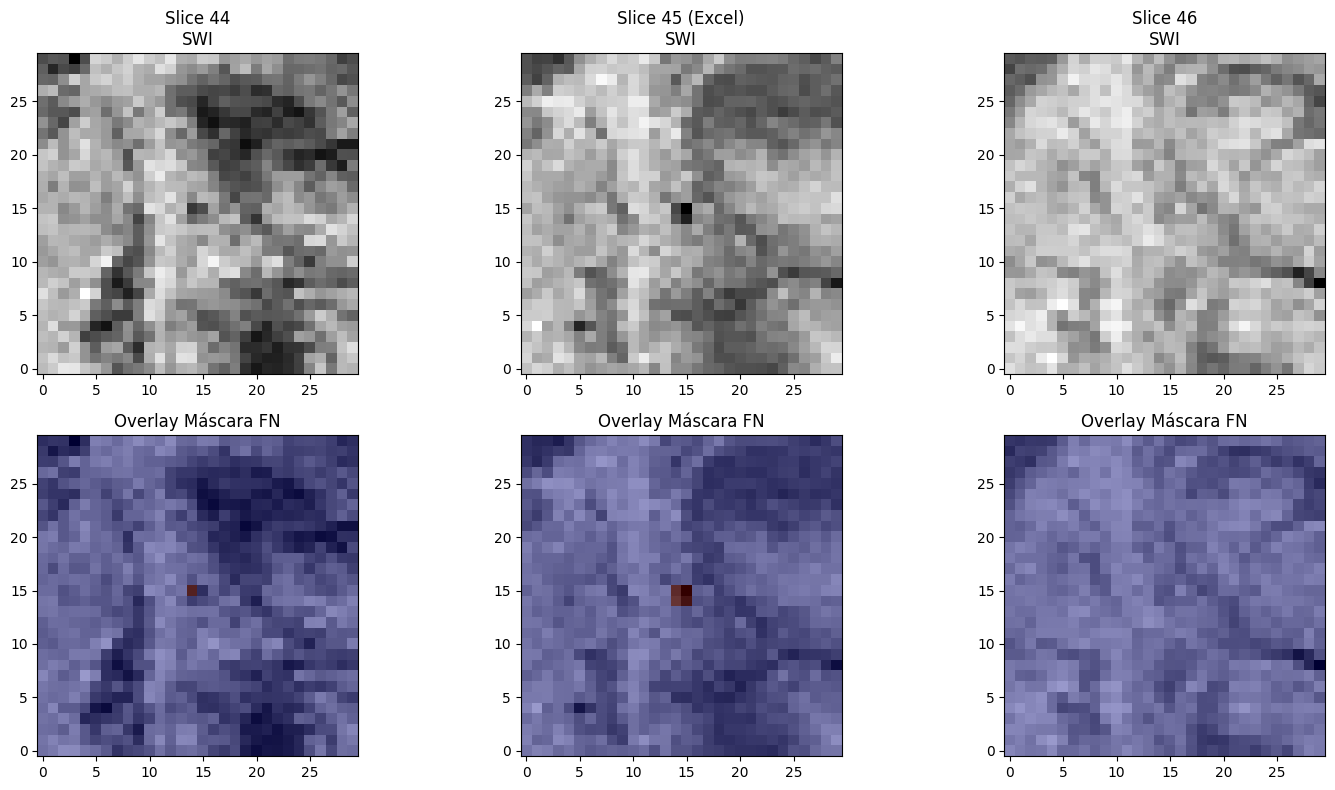

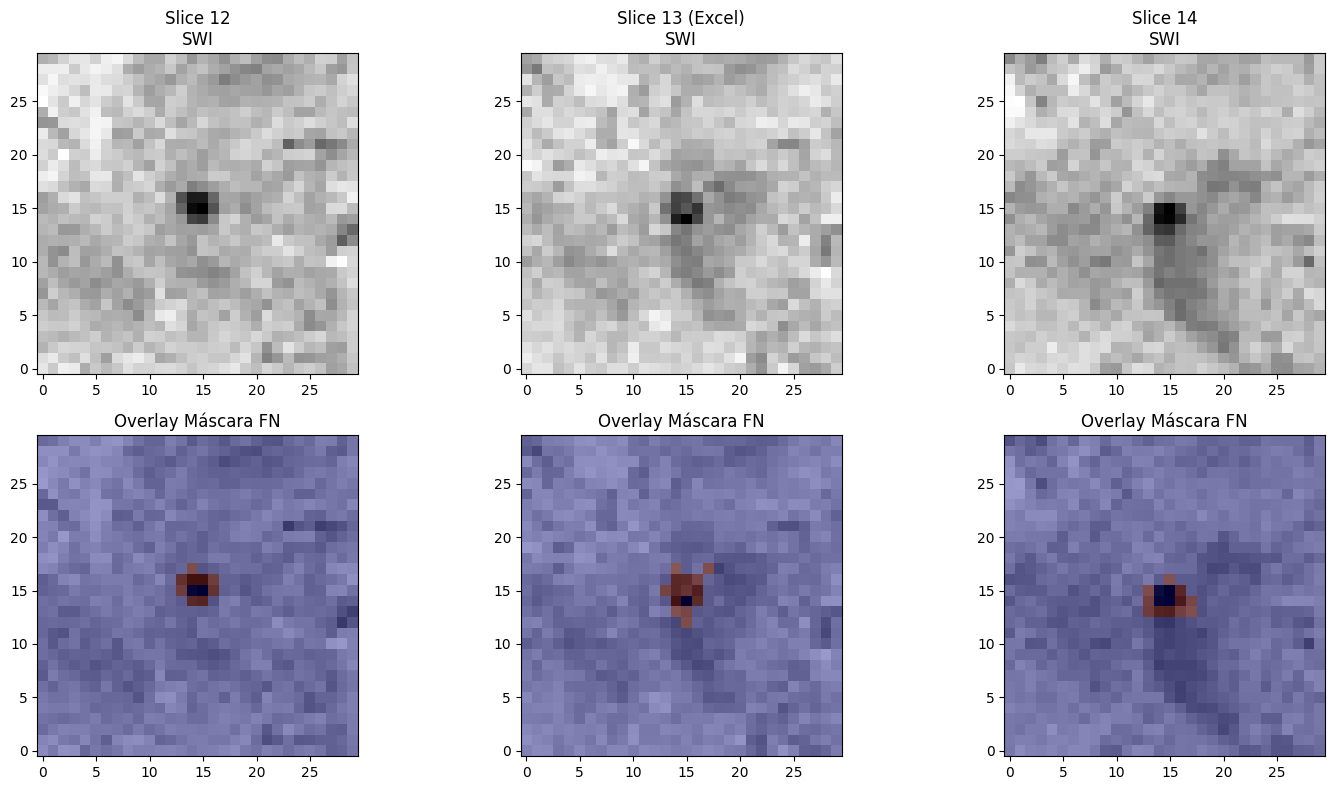

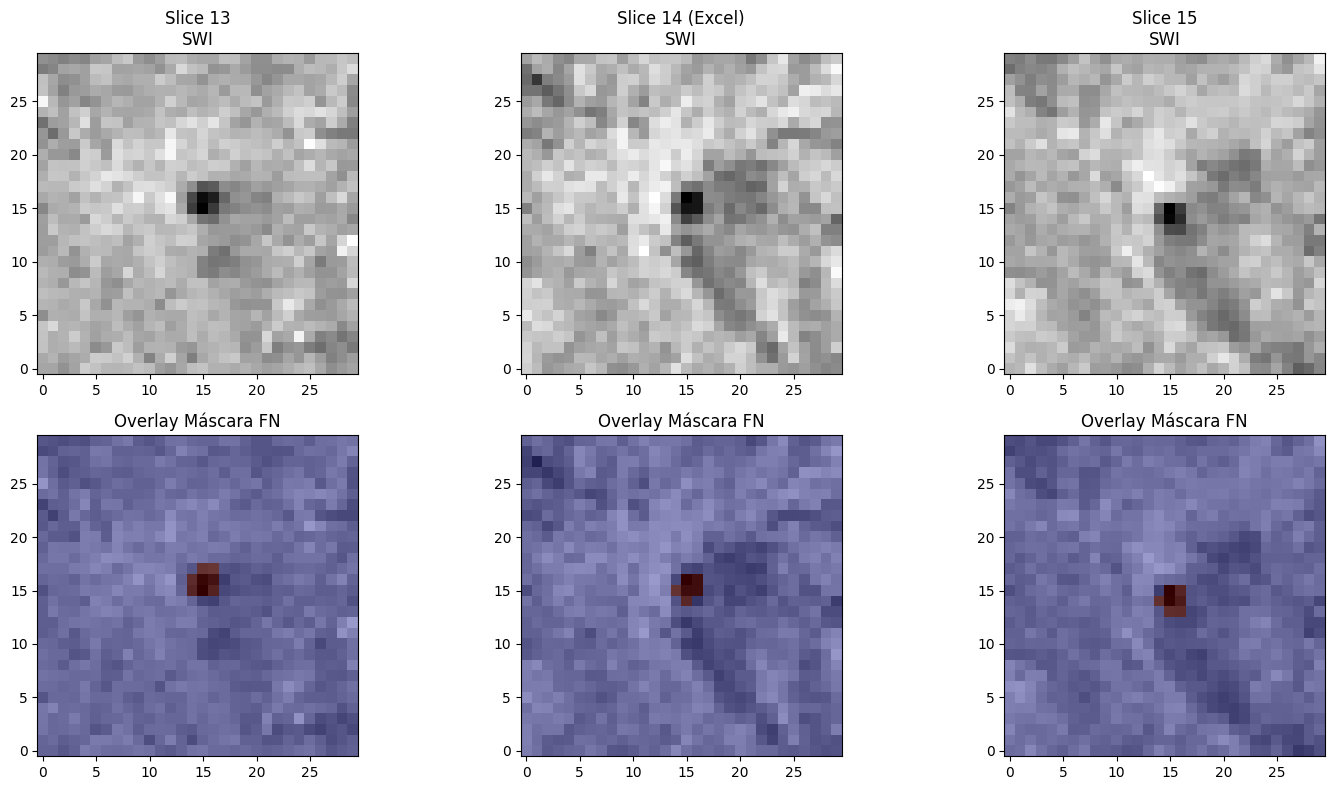

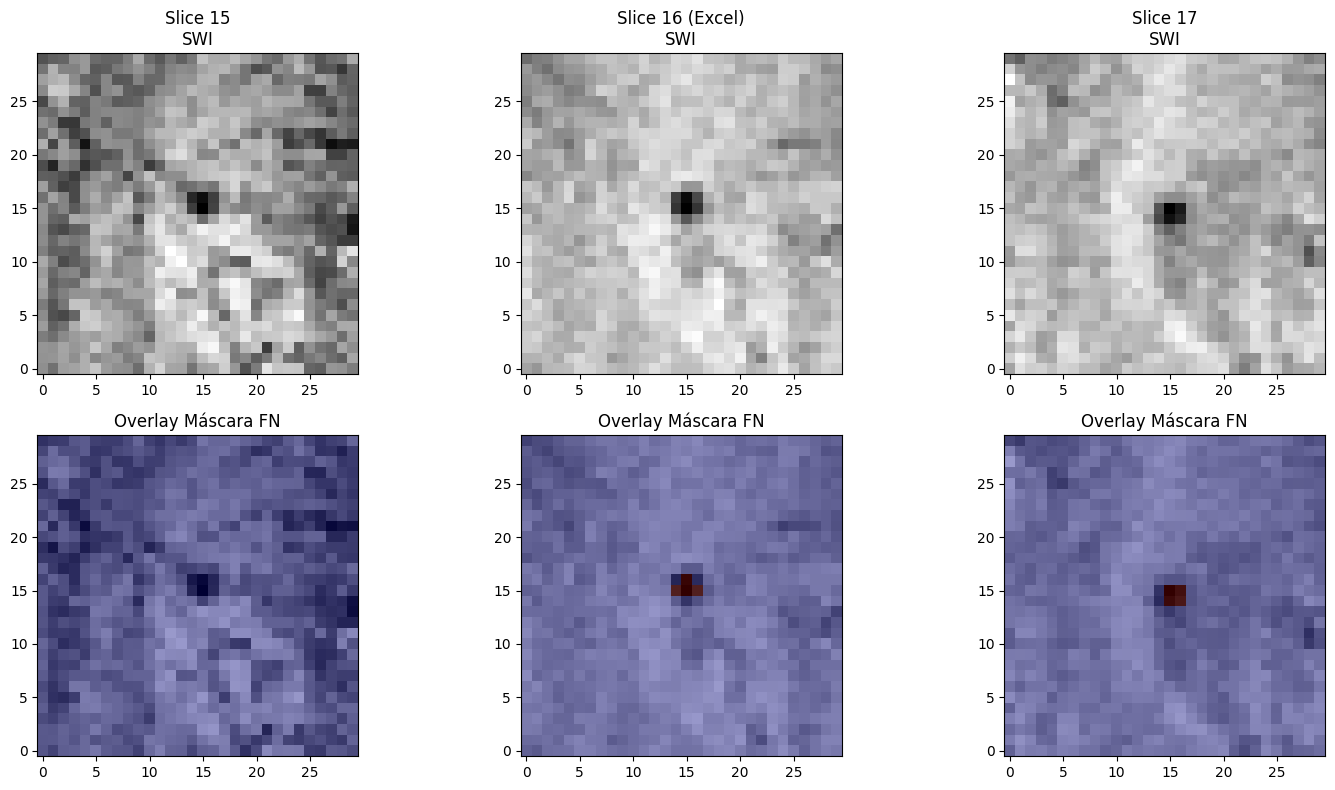

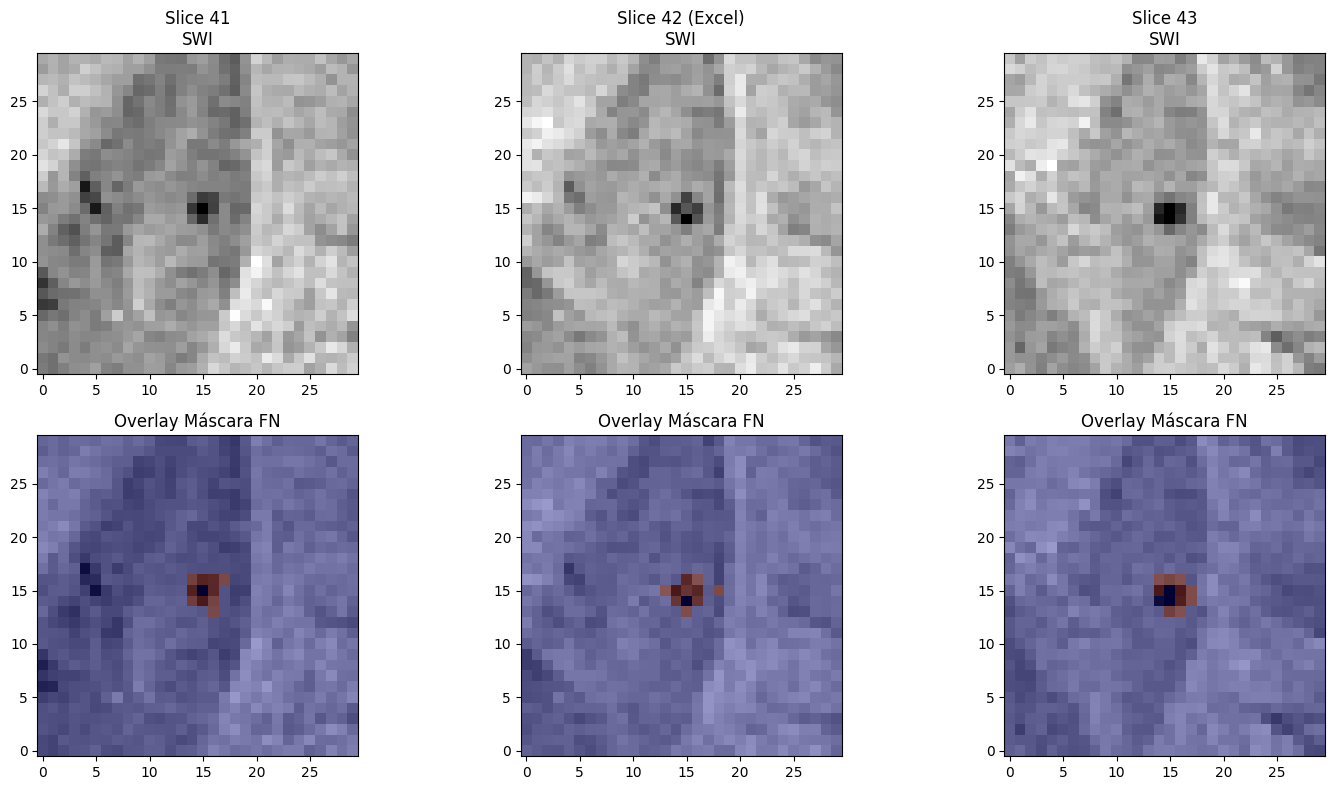

Finalizado. Mostrados 5 TPs y 5 FNs.


In [9]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from skimage.segmentation import flood
from scipy.ndimage import label

# CONFIGURACIÓN DE RUTAS
SWI_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_Real_CMBs_Test/imagesTs"
MASK_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/nnUNet_results/Dataset112_SyntheticCMB/nnUNet_3D_fullres_smallpatch_50epochs contra rCMBs/nnUNet_3D_fullres_smallpatch_50epochs_predicciones_test_rCMBs"
EXCEL_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_dataset/rCMBInformationInfo.xlsx"

MAX_EXAMPLES = 5  # Cuántos ejemplos mostrar de cada tipo
TOLERANCE = 0.04  # Umbral para el Flood Fill

def safe_int_minus1(val):
    try:
        if pd.isna(val) or str(val).strip() == "": return None
        return int(float(str(val))) - 1
    except:
        return None

def get_flood_mask(data, seed_coords, tolerance=0.04, max_radius=3):
    """Region Growing: data debe estar normalizada (0-1)."""
    # flood espera (x, y, z) si el array es (X, Y, Z)
    try:
        mask = flood(data, seed_coords, tolerance=tolerance)
        x_dim, y_dim, z_dim = data.shape
        x_i, y_i, z_i = np.ogrid[:x_dim, :y_dim, :z_dim]
        dist_sq = (x_i - seed_coords[0])**2 + (y_i - seed_coords[1])**2 + (z_i - seed_coords[2])**2
        mask = mask & (dist_sq <= max_radius**2)
        return mask.astype(np.uint8)
    except Exception as e:
        print(f"Error en flood fill: {e}")
        return np.zeros(data.shape, dtype=np.uint8)

def show_multislice_comparison(img_data, mask_data, coords, tipo_label, title):
    x, y, z = coords
    # Mostramos 3 cortes: el anterior, el central (Excel) y el posterior
    # Tipo label: TP o FN
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    x_min, x_max = max(0, x-15), min(img_data.shape[0], x+15)
    y_min, y_max = max(0, y-15), min(img_data.shape[1], y+15)
    
    slices = [z-1, z, z+1]
    titles = [f"Slice {z}", f"Slice {z+1} (Excel)", f"Slice {z+2}"]

    for i, s in enumerate(slices):
        if 0 <= s < img_data.shape[2]:
            img_patch = img_data[x_min:x_max, y_min:y_max, s]
            mask_patch = mask_data[x_min:x_max, y_min:y_max, s]
            
            # Fila 0: SWI original
            axes[0, i].imshow(img_patch.T, cmap='gray', origin='lower')
            axes[0, i].set_title(f"{titles[i]}\nSWI")
            
            # Fila 1: Overlay
            axes[1, i].imshow(img_patch.T, cmap='gray', origin='lower')
            axes[1, i].imshow(mask_patch.T, cmap='jet', alpha=0.4, origin='lower')
            axes[1, i].set_title(f"Overlay Máscara {tipo_label}")
    
    plt.tight_layout()
    plt.show()

# --- PROCESAMIENTO ---
if not os.path.exists(EXCEL_PATH):
    raise FileNotFoundError(f"No se encuentra el Excel en {EXCEL_PATH}")

df = pd.read_excel(EXCEL_PATH)
tp_count, fn_count = 0, 0

for idx, row in df.iterrows():
    if tp_count >= MAX_EXAMPLES and fn_count >= MAX_EXAMPLES:
        break

    nifti_name = str(row.iloc[0]).strip()
    if not nifti_name.endswith('.nii.gz'): continue

    swi_path = os.path.join(SWI_DIR, nifti_name.replace('.nii.gz', '_0000.nii.gz'))
    mask_path = os.path.join(MASK_DIR, nifti_name)
    
    if not os.path.exists(swi_path):
        print(f"Skipping {nifti_name}: No se encuentra la SWI en {swi_path}")
        continue
    if not os.path.exists(mask_path):
        print(f"Skipping {nifti_name}: No se encuentra la predicción en {mask_path}")
        continue

    # Carga de datos
    swi_nii = nib.load(swi_path)
    swi_data = swi_nii.get_fdata()
    # Normalización para el algoritmo de inundación
    swi_norm = (swi_data - np.min(swi_data)) / (np.max(swi_data) - np.min(swi_data) + 1e-8)
    
    mask_data = nib.load(mask_path).get_fdata()
    labeled_mask, _ = label(mask_data > 0)

    # Extraer coordenadas del Excel
    for i in range(1, len(row), 3):
        x = safe_int_minus1(row.iloc[i])
        y = safe_int_minus1(row.iloc[i+1])
        z = safe_int_minus1(row.iloc[i+2])
        
        if x is None or y is None or z is None: continue
        
        # 1. Verificar si es TP (Detección de la red en d <= 2)
        crop = labeled_mask[max(0,x-2):x+3, max(0,y-2):y+3, max(0,z-2):z+3]
        
        if np.any(crop > 0):
            if tp_count < MAX_EXAMPLES:
                blob_id = int(np.max(crop))
                tp_mask = (labeled_mask == blob_id).astype(np.uint8)
                # Llamada con título dinámico TP
                show_multislice_comparison(swi_data, tp_mask, (x, y, z), "TP", nifti_name)
                tp_count += 1
        else:
            if fn_count < MAX_EXAMPLES:
                # 2. Es un FN: Generamos pseudomáscara con tolerancia aumentada a 0.06
                fn_mask = get_flood_mask(swi_norm, (x, y, z), tolerance=0.06)
                if np.any(fn_mask):
                    # Llamada con título dinámico FN
                    show_multislice_comparison(swi_data, fn_mask, (x, y, z), "FN", nifti_name)
                    fn_count += 1

print(f"Finalizado. Mostrados {tp_count} TPs y {fn_count} FNs.")

Se descartaron las predicciones previas del modelo como Ground Truth por ser excesivamente conservadoras, optando por un algoritmo de crecimiento de regiones guiado por intensidad que capturara mejor el efecto de blooming real de las rCMBs.

De este modo, tanto para los TP como para los FN se ha realizado el algoritmo de Flood para crear las pseudomáscaras y usar estos datos para fine tunning.

In [14]:
import os
import random
import json
import shutil
import numpy as np
import nibabel as nib
import pandas as pd
from skimage.segmentation import flood
from tqdm import tqdm

# --- CONFIGURACIÓN DE RUTAS ---
SWI_ORIGINAL_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_Real_CMBs_Test/imagesTs"
EXCEL_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_dataset/rCMBInformationInfo.xlsx"

# Nueva carpeta para el Trial 5 (Dataset 115 - Fine Tunning)
OUTPUT_DATASET_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/nnUNet_raw/Dataset115_RealFineTuning"

# Parámetros técnicos
TRAIN_COUNT = 42
FLOOD_TOLERANCE = 0.04
MAX_RADIUS = 3

# --- CREACIÓN DE ESTRUCTURA NNUNET ---
folders = ["imagesTr", "labelsTr", "imagesTs", "labelsTs"]
for folder in folders:
    os.makedirs(os.path.join(OUTPUT_DATASET_DIR, folder), exist_ok=True)

def safe_int_minus1(val):
    try:
        if pd.isna(val) or str(val).strip() == "": return None
        return int(float(str(val))) - 1
    except: return None

def get_flood_mask(data, seed_coords, tolerance=0.06, radius=3):
    try:
        mask = flood(data, seed_coords, tolerance=tolerance)
        x_dim, y_dim, z_dim = data.shape
        x_i, y_i, z_i = np.ogrid[:x_dim, :y_dim, :z_dim]
        dist_sq = (x_i-seed_coords[0])**2 + (y_i-seed_coords[1])**2 + (z_i-seed_coords[2])**2
        return (mask & (dist_sq <= radius**2)).astype(np.uint8)
    except: return np.zeros(data.shape, dtype=np.uint8)

# 1. Realizar el Split
all_files = [f for f in os.listdir(SWI_ORIGINAL_DIR) if f.endswith("_0000.nii.gz")]
subjects = sorted([f.replace("_0000.nii.gz", "") for f in all_files])
random.seed(42)
random.shuffle(subjects)

train_subs = subjects[:TRAIN_COUNT]
test_subs = subjects[TRAIN_COUNT:]

# Guardar el JSON del split en la carpeta del dataset para tenerlo ordenado
with open(os.path.join(OUTPUT_DATASET_DIR, "split_info.json"), "w") as f:
    json.dump({"train": train_subs, "test": test_subs}, f, indent=4)

df_excel = pd.read_excel(EXCEL_PATH)

# 2. Procesar sujetos (Copia de imágenes + Generación de máscaras)
print("Organizando Dataset 115...")

for sub_id in tqdm(subjects):
    is_train = sub_id in train_subs
    img_folder = "imagesTr" if is_train else "imagesTs"
    lbl_folder = "labelsTr" if is_train else "labelsTs"
    
    # Ruta origen y destino de la imagen
    src_img = os.path.join(SWI_ORIGINAL_DIR, f"{sub_id}_0000.nii.gz")
    dst_img = os.path.join(OUTPUT_DATASET_DIR, img_folder, f"{sub_id}_0000.nii.gz")
    
    if not os.path.exists(src_img): continue
    
    # COPIAR IMAGEN ORIGINAL AL OUTPUT
    shutil.copyfile(src_img, dst_img)
    
    # GENERAR MÁSCARA (Solo si es entrenamiento, o si quieres tener las de test para evaluar)
    swi_nii = nib.load(src_img)
    swi_data = swi_nii.get_fdata()
    den = (np.max(swi_data) - np.min(swi_data))
    swi_norm = (swi_data - np.min(swi_data)) / (den if den > 0 else 1.0)
    
    final_mask = np.zeros(swi_data.shape, dtype=np.uint8)
    row = df_excel[df_excel.iloc[:, 0].str.contains(sub_id, na=False)]
    
    if not row.empty:
        row = row.iloc[0]
        for i in range(1, len(row), 3):
            x, y, z = safe_int_minus1(row.iloc[i]), safe_int_minus1(row.iloc[i+1]), safe_int_minus1(row.iloc[i+2])
            if all(v is not None for v in [x, y, z]):
                if 0 <= x < swi_data.shape[0] and 0 <= y < swi_data.shape[1] and 0 <= z < swi_data.shape[2]:
                    cmb_mask = get_flood_mask(swi_norm, (x, y, z), FLOOD_TOLERANCE, MAX_RADIUS)
                    final_mask = np.logical_or(final_mask, cmb_mask)
    
    # Guardar máscara (sin el sufijo _0000)
    dst_lbl = os.path.join(OUTPUT_DATASET_DIR, lbl_folder, f"{sub_id}.nii.gz")
    mask_nii = nib.Nifti1Image(final_mask.astype(np.uint8), swi_nii.affine, swi_nii.header)
    nib.save(mask_nii, dst_lbl)

print(f"Dataset 115 listo en: {OUTPUT_DATASET_DIR}")

# 3. Generación AUTOMÁTICA del dataset.json
print("Generando dataset.json...")
num_training = len([f for f in os.listdir(os.path.join(OUTPUT_DATASET_DIR, "imagesTr")) if f.endswith("_0000.nii.gz")])

dataset_info = {
    "channel_names": {"0": "SWI"},
    "labels": {"background": 0, "CMB": 1},
    "numTraining": num_training,
    "file_ending": ".nii.gz",
    "overwrite_image_reader_writer": "NibabelIOWithPrecomputedGeometry"
}

with open(os.path.join(OUTPUT_DATASET_DIR, "dataset.json"), "w") as f:
    json.dump(dataset_info, f, indent=4)

print(f"Dataset 115 completado y configurado para nnU-Net.")


Organizando Dataset 115...


100%|██████████| 57/57 [00:09<00:00,  5.86it/s]

Dataset 115 listo en: /media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/nnUNet_raw/Dataset115_RealFineTuning
Generando dataset.json...
Dataset 115 completado y configurado para nnU-Net.
